# Importing Necessary Files

In [124]:
%run /content/XHE.ipynb
%run /content/CEHE.ipynb

# Importing Necessary Packages

In [116]:
import os
import numpy as np
import zipfile
import tarfile
import random
import nibabel as nib
import matplotlib.pyplot as plt
from google.colab import drive
from scipy.signal import convolve

# Unzipping the dataset and Getting a Random Validation Set for CEHE

## A) Unzipping Data

In [2]:
# Unzipping Data from Google Drive
drive.mount('/content/drive')
zipped_data = "/content/drive/MyDrive/ColabData/GP-Datasets/brats-2021-task1.zip"
extract_path = "/content/brats-2021-task1"
with zipfile.ZipFile(zipped_data, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

Mounted at /content/drive


In [3]:
tar_training_data = extract_path + "/BraTS2021_Training_Data.tar"
training_data_path = extract_path + '/training_data'
with tarfile.open(tar_training_data, 'r') as tar_ref:
    tar_ref.extractall(training_data_path)
os.remove(tar_training_data)

## B) Getting a Random Validation Set for CEHE

In [139]:
samples = os.listdir(training_data_path)
random.seed(42)
validation_samples = random.sample(samples, 5)

# Implementing Measures to compare CEHE with Standard HE

We have actually tried different algorithms such as LHE but it seems not appropriate for our purposes.
Look at the XHE.ipynb file

## Measuring Contrast of each Voxel

In [118]:
def measure_contrast(nii_image_arr):
  # Getting the Image as a 3D Array of values
  image_arr = nii_image.get_fdata()
  output_arr = np.zeros(nii_image.shape)
  # Defining a filter to measure the contrast
  contrast_filter = np.ones((3, 3, 3)) * -1
  contrast_filter[1, 1, 1] = 26
  # Pad the image and apply the above filter
  padded_image_arr = np.pad(image_arr, ((1, 1), (1, 1), (1, 1)), mode='edge')
  filtered_arr = convolve(padded_image_arr, contrast_filter, mode='valid')
  # returning average sum of absolute the contrast of each pixel
  return (np.abs(filtered_arr) / output_arr.size).sum()

## Measuring Histogram Flatness

In [125]:
def measure_histogram_flatness(nii_image):
  # Getting the Image as a 3D Array of values
  image_arr = nii_image.get_fdata()
  # Computing the Histogram of 65536 bins from the image
  histogram, bin_edges = np.histogram(image_arr, bins=2 ** 16)
  # Calculating Average Value Stored in the Histogram
  mean_histo_value = np.mean(histogram)
  # Calculating SD and Variance of the Histogram
  sd = histogram - mean_histo_value
  return np.sum(sd * sd) / (2 ** 16)

## Measuring the SD of local change in contrast.

In [113]:
def measure_sd_local_contrast_change(enhanced_nii_image, original_nii_image):
  # Getting the Image as a 3D Array of values
  enhanced_image_arr = enhanced_nii_image.get_fdata()
  original_image_arr = original_nii_image.get_fdata()
  # Setting zero voxels to -1 to do division
  original_image_arr[enhanced_image_arr == 0] = -1
  # Measuring Change in Local Contrast
  contrast_change = original_image_arr / enhanced_image_arr
  contrast_change[contrast_change < 0] = original_image_arr[contrast_change < 0]
  # Measuring Mean Change
  mean_contrast_change = np.mean(contrast_change)
  # Measuring SD of the Change
  sd_contrast_change = contrast_change - mean_contrast_change
  sd_contrast_change = np.sum(sd_contrast_change * sd_contrast_change)
  return sd_contrast_change / original_image_arr.size

# Comparisons

In [140]:
enhanced_images_cehe_voting = []
enhanced_images_cehe_inverted_avg = []
enhanced_images_cehe_avg = []
enhanced_images_she = []
normalized_validation_images = []

## Normalizing Images

In [141]:
for i in range(len(validation_samples)):
  sample_name = validation_samples[i]
  flair_path = training_data_path + f"/{sample_name}/{sample_name}_flair.nii.gz"
  normalized_image = normalize(nib.load(flair_path))
  normalized_validation_images.append(normalized_image.get_fdata())

## Enhancing Validation Images by CEHE-NeighbourHood Voting Metric:

In [143]:
for image_arr in normalized_validation_images:
  enhanced_images_cehe_voting.append(CEHE(image_arr, neighbourhood_voting_fn, 3, 65536))

## Enhancing Validation Images by CEHE-InvertedAvg Metric:

In [144]:
for image_arr in normalized_validation_images:
  enhanced_images_cehe_inverted_avg.append(CEHE(image_arr, inverted_average_fn, 3, 65536))

## Enhancing Validation Images by CEHE-Average Metric:

In [148]:
for image_arr in normalized_validation_images:
  enhanced_images_cehe_avg.append(CEHE(image_arr, average_fn, 3, 65536))

## Normalizing CEHE enhanced images

In [156]:
for i in range(len(normalized_validation_images)):
  enhanced_images_cehe_voting[i] = normalize(nib.Nifti1Image(enhanced_images_cehe_voting[i], affine=np.eye(4)))
  enhanced_images_cehe_avg[i] = normalize(nib.Nifti1Image(enhanced_images_cehe_avg[i], affine=np.eye(4)))
  enhanced_images_cehe_inverted_avg[i] = normalize(nib.Nifti1Image(enhanced_images_cehe_inverted_avg[i], affine=np.eye(4)))

## Enhancing Validation Images by SHE:

In [151]:
for image_arr in normalized_validation_images:
  image = nib.Nifti1Image(image_arr, affine=np.eye(4))
  enhanced_images_she.append(global_histogram_equalization(image))

## 1) In terms of Contrast Per Pixel

In [160]:
orignal_image_contrast = []
SHE_image_contrast = []
CEHE_neighborvoting_image_contrast = []
CEHE_avg_image_contrast = []
CEHE_invAVG_image_contrast = []

for i in range(len(validation_samples)):
  image = nib.Nifti1Image(normalized_validation_images[i], affine=np.eye(4))
  orignal_image_contrast.append(measure_contrast(image))

  image = nib.Nifti1Image(enhanced_images_she[i], affine=np.eye(4))
  SHE_image_contrast.append(measure_contrast(image))

  image = enhanced_images_cehe_inverted_avg[i]
  CEHE_invAVG_image_contrast.append(measure_contrast(image))

  image = enhanced_images_cehe_voting[i]
  CEHE_neighborvoting_image_contrast.append(measure_contrast(image))

  image = enhanced_images_cehe_avg[i]
  CEHE_avg_image_contrast.append(measure_contrast(image))

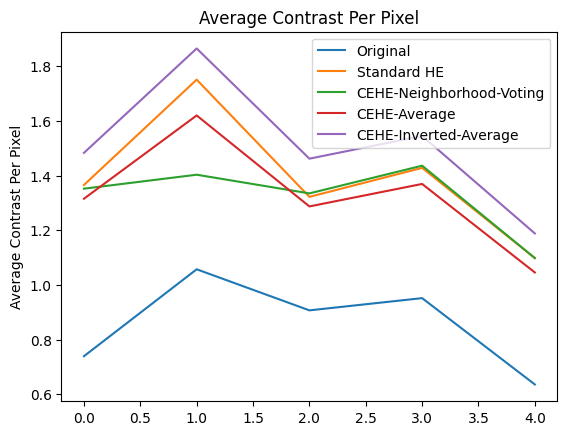

In [163]:
plt.plot(orignal_image_contrast, label='Original')
plt.plot(SHE_image_contrast, label='Standard HE')
plt.plot(CEHE_neighborvoting_image_contrast, label='CEHE-Neighborhood-Voting')
plt.plot(CEHE_avg_image_contrast, label='CEHE-Average')
plt.plot(CEHE_invAVG_image_contrast, label='CEHE-Inverted-Average')

# Adding labels and title
plt.ylabel('Average Contrast Per Pixel')
plt.title('Average Contrast Per Pixel')
plt.legend()
plt.show()

In [164]:
orignal_histo_flatness = []
SHE_histo_flatness = []
CEHE_neighborvoting_histo_flatness = []
CEHE_avg_histo_flatness = []
CEHE_invAVG_histo_flatness = []

for i in range(len(validation_samples)):
  image = nib.Nifti1Image(normalized_validation_images[i], affine=np.eye(4))
  orignal_histo_flatness.append(measure_histogram_flatness(image))

  image = nib.Nifti1Image(enhanced_images_she[i], affine=np.eye(4))
  SHE_histo_flatness.append(measure_histogram_flatness(image))

  image = enhanced_images_cehe_inverted_avg[i]
  CEHE_invAVG_histo_flatness.append(measure_histogram_flatness(image))

  image = enhanced_images_cehe_voting[i]
  CEHE_neighborvoting_histo_flatness.append(measure_histogram_flatness(image))

  image = enhanced_images_cehe_avg[i]
  CEHE_avg_histo_flatness.append(measure_histogram_flatness(image))


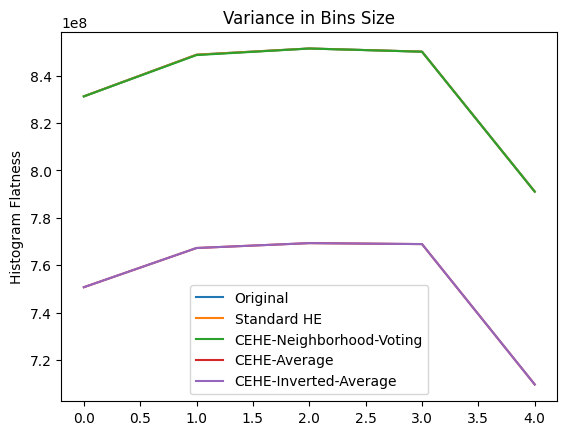

In [169]:
plt.plot(orignal_histo_flatness, label='Original')
plt.plot(SHE_histo_flatness, label='Standard HE')
plt.plot(CEHE_neighborvoting_histo_flatness, label='CEHE-Neighborhood-Voting')
plt.plot(CEHE_avg_histo_flatness, label='CEHE-Average')
plt.plot(CEHE_invAVG_histo_flatness, label='CEHE-Inverted-Average')

# Adding labels and title
plt.ylabel('Histogram Flatness')
plt.title('Variance in Bins Size')
plt.legend()
plt.show()

In [170]:
orignal_SHE_image_distortion = []
original_cehe_voting_image_distortions = []
original_cehe_avg_image_distortions = []
original_cehe_inv_avg_image_distortions = []


for i in range(len(validation_samples)):
  original_image = nib.Nifti1Image(normalized_validation_images[i], affine=np.eye(4))
  she_image = nib.Nifti1Image(enhanced_images_she[i], affine=np.eye(4))

  orignal_SHE_image_distortion.append(measure_sd_local_contrast_change(she_image, original_image))

  invavg_image = enhanced_images_cehe_inverted_avg[i]
  original_cehe_inv_avg_image_distortions.append(measure_sd_local_contrast_change(invavg_image, original_image))

  voting_image = enhanced_images_cehe_voting[i]
  original_cehe_voting_image_distortions.append(measure_sd_local_contrast_change(voting_image, original_image))

  avg_image = enhanced_images_cehe_avg[i]
  original_cehe_avg_image_distortions.append(measure_sd_local_contrast_change(avg_image, original_image))


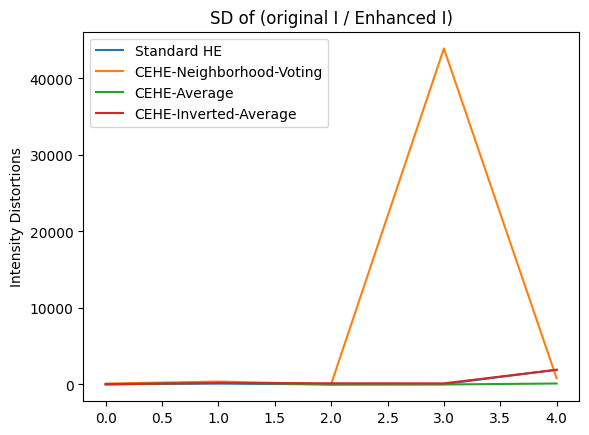

In [171]:
plt.plot(orignal_SHE_image_distortion, label='Standard HE')
plt.plot(original_cehe_voting_image_distortions, label='CEHE-Neighborhood-Voting')
plt.plot(original_cehe_avg_image_distortions, label='CEHE-Average')
plt.plot(original_cehe_inv_avg_image_distortions, label='CEHE-Inverted-Average')

# Adding labels and title
plt.ylabel('Intensity Distortions')
plt.title('SD of (original I / Enhanced I)')
plt.legend()
plt.show()

# Sample Case  

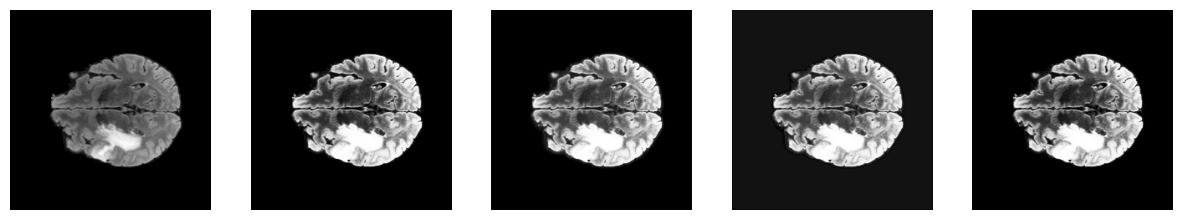

In [176]:
original_image_arr = normalized_validation_images[2]
she_image_arr = enhanced_images_she[2]
cehe_image_arr_avg = enhanced_images_cehe_avg[2].get_fdata()
cehe_image_arr_inv_avg = enhanced_images_cehe_inverted_avg[2].get_fdata()
cehe_image_arr_nvoting = enhanced_images_cehe_voting[2].get_fdata()

f = plt.figure(figsize=(15, 15))
f.add_subplot(1, 5, 1)
plt.imshow(original_image_arr[:, :, 70], cmap='gray')
plt.axis('off')

f.add_subplot(1, 5, 2)
plt.imshow(she_image_arr[:, :, 70], cmap='gray')
plt.axis('off')

f.add_subplot(1, 5, 3)
plt.imshow(cehe_image_arr_avg[:, :, 70], cmap='gray')
plt.axis('off')

f.add_subplot(1, 5, 4)
plt.imshow(cehe_image_arr_inv_avg[:, :, 70], cmap='gray')
plt.axis('off')

f.add_subplot(1, 5, 5)
plt.imshow(cehe_image_arr_nvoting[:, :, 70], cmap='gray')
plt.axis('off')

plt.show()